# Zimbabwe Real Estate Price Prediction System
## Phase 2 - Data Cleaning & Preprocessing

**Input:** raw CSV | **Output:** data/processed/properties_clean.csv + src/data_preprocessing.py

| Step | Action |
|------|--------|
| 1 | Remove duplicate listings (36 duplicate URLs) |
| 2 | Drop high-missingness columns (payment_terms 97.7%, agent_name 67.6%, agency_name 67.1%) |
| 3 | Drop rows with missing price (14 rows) |
| 4 | Fix invalid values (bathrooms=11000, zero floor_area/land_size, floor_area<30m2) |
| 5 | Cap price outliers (below $5K removed, above 99th pct $1.8M capped) |
| 6 | Cap bedroom/bathroom outliers in single Houses |
| 7 | Impute floor_area (median by bedrooms x house_category) |
| 8 | Impute bathrooms (median by bedrooms) |
| 9 | Impute land_size (median by region) |
| 10 | Clean compound region names; infer missing region from suburb |
| 11 | Standardise house_type to 4 categories |
| 12 | Re-engineer all derived columns on clean values |
| 13 | Quality filter (data_quality_score >= 5) |
| 14 | Encode categoricals (binary, ordinal, target encoding) |
| 15 | Add log_price target |
| 16 | Save cleaned CSV + preprocessing script |

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)

PALETTE = ["#1A1A2E","#E94560","#27AE60","#F39C12","#2980B9","#8E44AD"]
SEG_COLORS = {"Budget":"#27AE60","Mid":"#2980B9","Premium":"#F39C12","Luxury":"#E94560"}
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"#FAFAFA",
                     "axes.grid":True,"grid.alpha":0.4})

FIG_DIR = "reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("src", exist_ok=True)

def save(name):
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=300, bbox_inches="tight")
    plt.show()

print("Setup complete.")

Setup complete.


In [2]:
DATA_PATH = "data/raw/property_phase1_engineered.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "property_phase1_engineered.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
cleaning_log = []

def log_step(step, desc, r_before, r_after, c_before=None, c_after=None):
    cleaning_log.append({"Step":step,"Description":desc,
                         "Rows Before":r_before,"Rows After":r_after,
                         "Rows Dropped":r_before-r_after})
    print(f"[{step}] {desc}")
    print(f"       Rows: {r_before:,} -> {r_after:,}  (dropped {r_before-r_after:,})")
    if c_before: print(f"       Cols: {c_before} -> {c_after}")
    print()

print(f"Raw shape: {df.shape[0]:,} rows x {df.shape[1]} cols")

Raw shape: 2,036 rows x 41 cols


---
## Steps 1-2: Remove Duplicates & Drop Metadata Columns

In [3]:
# Step 1: Duplicates
r0 = len(df)
df = df[~df.duplicated(subset=["listing_url"], keep="first")].reset_index(drop=True)
log_step("01", "Remove duplicate listing URLs", r0, len(df))

# Step 2: Drop high-missingness & metadata columns
DROP_COLS = ["payment_terms","agent_name","agency_name","listing_url","scraped_date"]
r0, c0 = len(df), df.shape[1]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
log_step("02", "Drop high-missingness & metadata columns", r0, len(df), c0, df.shape[1])

[01] Remove duplicate listing URLs
       Rows: 2,036 -> 2,000  (dropped 36)

[02] Drop high-missingness & metadata columns
       Rows: 2,000 -> 2,000  (dropped 0)
       Cols: 41 -> 36



---
## Steps 3-4: Drop Missing Price & Fix Invalid Values

In [4]:
# Step 3: Drop missing price
r0 = len(df)
df = df[df["price"].notna()].reset_index(drop=True)
log_step("03", "Drop rows missing price (target variable)", r0, len(df))

# Step 4: Fix invalid values
r0 = len(df)
print(f"Bathrooms > 50 (errors): {(df["bathrooms"] > 50).sum()}")
df.loc[df["bathrooms"] > 50, "bathrooms"] = np.nan

print(f"floor_area == 0: {(df["floor_area"]==0).sum()} -> NaN")
df["floor_area"] = df["floor_area"].replace(0, np.nan)

print(f"land_size == 0: {(df["land_size"]==0).sum()} -> NaN")
df["land_size"] = df["land_size"].replace(0, np.nan)

print(f"floor_area < 30m2: {(df["floor_area"] < 30).sum()} -> NaN")
df.loc[df["floor_area"] < 30, "floor_area"] = np.nan

log_step("04", "Fix impossible values (bathroom=11000, zero/tiny floor_area, zero land_size)", r0, len(df))

[03] Drop rows missing price (target variable)
       Rows: 2,000 -> 1,986  (dropped 14)

Bathrooms > 50 (errors): 1
floor_area == 0: 13 -> NaN
land_size == 0: 6 -> NaN
floor_area < 30m2: 35 -> NaN
[04] Fix impossible values (bathroom=11000, zero/tiny floor_area, zero land_size)
       Rows: 1,986 -> 1,986  (dropped 0)



---
## Step 5: Cap Price Outliers

Price floor: $5,000
Price ceiling (99th pct): $1,800,000
Rows below floor: 1
Rows above ceiling: 19


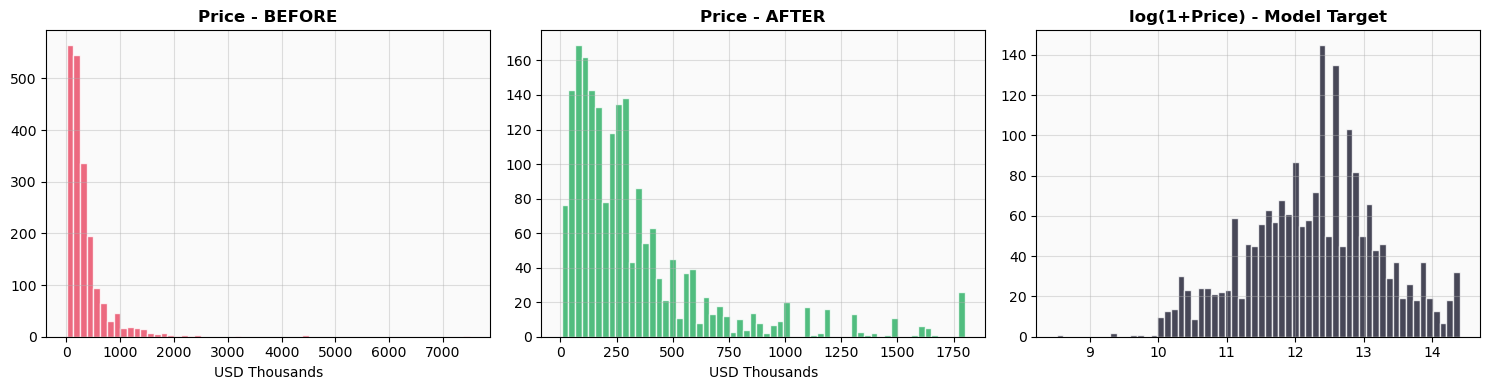

[05] Cap price outliers (floor=$5,000, ceiling=$1,800,000)
       Rows: 1,986 -> 1,985  (dropped 1)



In [5]:
r0 = len(df)
PRICE_LOW  = 5_000
PRICE_HIGH = df["price"].quantile(0.99)
print(f"Price floor: ${PRICE_LOW:,}")
print(f"Price ceiling (99th pct): ${PRICE_HIGH:,.0f}")
print(f"Rows below floor: {(df["price"] < PRICE_LOW).sum()}")
print(f"Rows above ceiling: {(df["price"] > PRICE_HIGH).sum()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df["price"]/1e3, bins=60, color="#E94560", edgecolor="white", alpha=0.8)
axes[0].set_title("Price - BEFORE", fontweight="bold")
axes[0].set_xlabel("USD Thousands")

df = df[df["price"] >= PRICE_LOW].reset_index(drop=True)
df["price"] = df["price"].clip(upper=PRICE_HIGH)
df["log_price"] = np.log1p(df["price"])

axes[1].hist(df["price"]/1e3, bins=60, color="#27AE60", edgecolor="white", alpha=0.8)
axes[1].set_title("Price - AFTER", fontweight="bold")
axes[1].set_xlabel("USD Thousands")

axes[2].hist(df["log_price"], bins=60, color="#1A1A2E", edgecolor="white", alpha=0.8)
axes[2].set_title("log(1+Price) - Model Target", fontweight="bold")

plt.tight_layout()
save("22_price_before_after")
log_step("05", f"Cap price outliers (floor=${PRICE_LOW:,}, ceiling=${PRICE_HIGH:,.0f})", r0, len(df))

---
## Steps 6-9: House Category & Imputation

In [6]:
# Step 6: House category & bedroom/bathroom cap
r0 = len(df)

def get_house_category(ht):
    if pd.isna(ht): return "House"
    ht = str(ht).lower()
    if "townhouse" in ht or "complex" in ht: return "Townhouse"
    if "flat" in ht or "apartment" in ht: return "Flat"
    if "unit" in ht: return "Unit"
    return "House"

df["house_category"] = df["house_type"].apply(get_house_category)
house_mask = df["house_category"] == "House"
df.loc[house_mask & (df["bedrooms"] > 12), "bedrooms"] = 12
df.loc[house_mask & (df["bathrooms"] > 15), "bathrooms"] = 15
log_step("06", "Add house_category; cap beds<=12 & baths<=15 for Houses", r0, len(df))

# Step 7: Impute floor_area
r0 = len(df)
missing_before = df["floor_area"].isnull().sum()
floor_med = df.groupby(["bedrooms","house_category"])["floor_area"].median()
def imp_floor(row):
    if pd.isna(row["floor_area"]):
        val = floor_med.get((row["bedrooms"], row["house_category"]), np.nan)
        return val if pd.notna(val) else df["floor_area"].median()
    return row["floor_area"]
df["floor_area"] = df.apply(imp_floor, axis=1)
print(f"floor_area: {missing_before} nulls -> {df["floor_area"].isnull().sum()}")
log_step("07", "Impute floor_area (median by bedrooms x house_category)", r0, len(df))

# Step 8: Impute bathrooms
missing_before = df["bathrooms"].isnull().sum()
bath_med = df.groupby("bedrooms")["bathrooms"].median()
df["bathrooms"] = df.apply(
    lambda r: bath_med.get(r["bedrooms"], df["bathrooms"].median())
    if pd.isna(r["bathrooms"]) else r["bathrooms"], axis=1)
print(f"bathrooms: {missing_before} nulls -> {df["bathrooms"].isnull().sum()}")
log_step("08", "Impute bathrooms (median by bedrooms)", r0, len(df))

# Step 9: Clean region & impute land_size
def clean_region(r):
    if pd.isna(r): return np.nan
    r = str(r).strip()
    if "," in r: r = r.split(",")[-1].strip()
    return r

df["region"] = df["region"].apply(clean_region)
land_med = df.groupby("region")["land_size"].median()
df["land_size"] = df.apply(
    lambda r: land_med.get(r["region"], df["land_size"].median())
    if pd.isna(r["land_size"]) else r["land_size"], axis=1)
sub_to_reg = (df.dropna(subset=["suburb","region"])
              .groupby("suburb")["region"]
              .agg(lambda x: x.mode()[0]).to_dict())
df.loc[df["region"].isna(), "region"] = df.loc[df["region"].isna(), "suburb"].map(sub_to_reg)
df["region"] = df["region"].fillna("Unknown")
df["suburb"] = df["suburb"].fillna("Unknown")
print(f"region nulls: {df["region"].isnull().sum()}")
print(f"suburb nulls: {df["suburb"].isnull().sum()}")
log_step("09", "Clean compound region names; impute land_size; fill unknown region/suburb", r0, len(df))

[06] Add house_category; cap beds<=12 & baths<=15 for Houses
       Rows: 1,985 -> 1,985  (dropped 0)

floor_area: 368 nulls -> 0
[07] Impute floor_area (median by bedrooms x house_category)
       Rows: 1,985 -> 1,985  (dropped 0)

bathrooms: 251 nulls -> 0
[08] Impute bathrooms (median by bedrooms)
       Rows: 1,985 -> 1,985  (dropped 0)

region nulls: 0
suburb nulls: 0
[09] Clean compound region names; impute land_size; fill unknown region/suburb
       Rows: 1,985 -> 1,985  (dropped 0)



---
## Steps 10-13: Re-engineer Features, Encode & Quality Filter

In [8]:
# Step 10: Re-engineer all derived columns
r0 = len(df)
AMENITY_COLS = ["has_pool","has_solar","has_borehole","has_garage",
                "has_garden","has_security","has_inverter","has_generator"]
for col in AMENITY_COLS:
    df[col] = df[col].astype(int)
df["furnished"] = df["furnished"].astype(int)

df["price_per_sqm_floor"] = (df["price"] / df["floor_area"]).replace([np.inf,-np.inf], np.nan)
df["price_per_bed"]       = (df["price"] / df["bedrooms"]).replace([np.inf,-np.inf], np.nan)
df["price_per_bath"]      = (df["price"] / df["bathrooms"]).replace([np.inf,-np.inf], np.nan)
df["price_per_hectare"]   = (df["price"] / (df["land_size"]/10000)).replace([np.inf,-np.inf], np.nan)
df["size_ratio"]          = (df["floor_area"] / df["land_size"]).replace([np.inf,-np.inf], np.nan)
df["value_density"]       = (df["price"] / df["land_size"]).replace([np.inf,-np.inf], np.nan)
df["bath_ratio"]          = (df["bathrooms"] / df["bedrooms"]).replace([np.inf,-np.inf], np.nan)
df["amenity_score"]       = df[["has_pool","has_garden","has_garage","has_security"]].sum(axis=1)
df["energy_score"]        = df[["has_solar","has_borehole","has_inverter","has_generator"]].sum(axis=1)
df["maintenance_burden"]  = df[["has_pool","has_garden","has_generator"]].sum(axis=1)
df["modern_amenities"]    = df[["has_solar","has_inverter","has_generator"]].sum(axis=1)
df["amenities_count"]     = df[AMENITY_COLS].sum(axis=1)

def assign_segment(price):
    if price < 120_000: return "Budget"
    if price < 250_000: return "Mid"
    if price < 500_000: return "Premium"
    return "Luxury"
df["segment"] = df["price"].apply(assign_segment)
log_step("10", "Re-engineer all derived columns on clean base values", r0, len(df))

# Step 11: Quality filter
r0 = len(df)
core_fields = ["price","suburb","region","bedrooms","bathrooms","floor_area","land_size"]
df["data_quality_score"] = df[core_fields].notna().sum(axis=1)
df = df[df["data_quality_score"] >= 5].reset_index(drop=True)
log_step("11", "Filter data_quality_score < 5", r0, len(df))

# Step 12: Encodings
df["segment_encoded"]         = df["segment"].map({"Budget":0,"Mid":1,"Premium":2,"Luxury":3})
df["region_price_enc"]        = df.groupby("region")["price"].transform("median")
df["suburb_price_enc"]        = df.groupby("suburb")["price"].transform("median")
df["house_category_encoded"]  = df["house_category"].map({"House":0,"Townhouse":1,"Flat":2,"Unit":3}).fillna(0).astype(int)
house_dummies = pd.get_dummies(df["house_category"], prefix="is", drop_first=False)
df = pd.concat([df, house_dummies], axis=1)
log_step("12", "Encode categoricals: ordinal segment, target-encode region/suburb, one-hot house_category", r0, len(df))

print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

[10] Re-engineer all derived columns on clean base values
       Rows: 1,985 -> 1,985  (dropped 0)

[11] Filter data_quality_score < 5
       Rows: 1,985 -> 1,985  (dropped 0)

[12] Encode categoricals: ordinal segment, target-encode region/suburb, one-hot house_category
       Rows: 1,985 -> 1,985  (dropped 0)

Final shape: 1,985 rows x 44 cols
Missing values remaining: 676


---
## Before vs After Visualisations

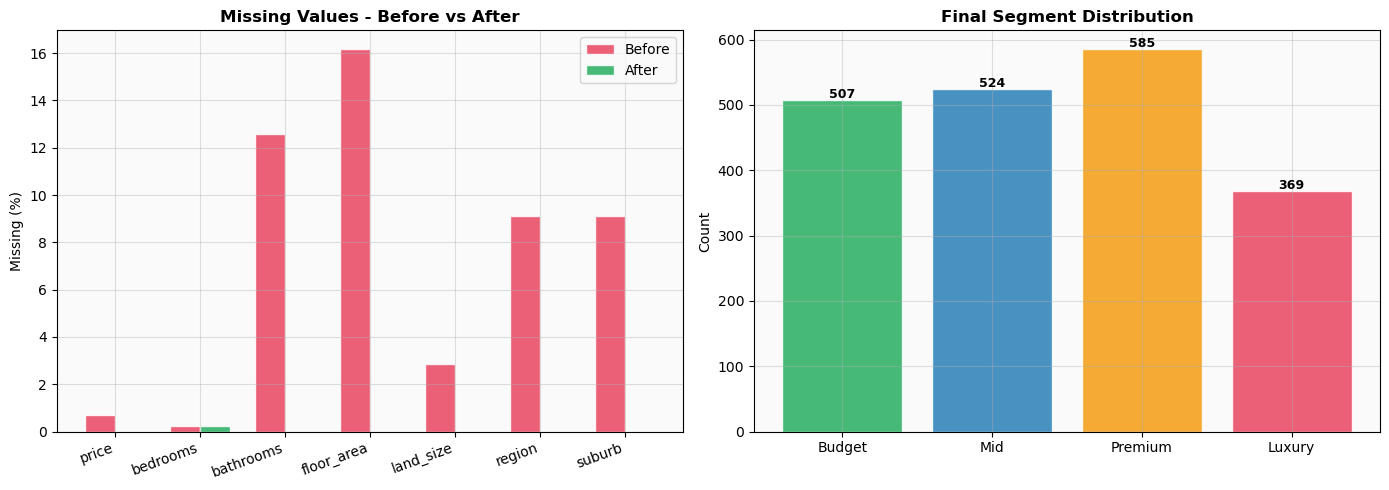

In [9]:
# Missing value comparison
key_cols = ["price","bedrooms","bathrooms","floor_area","land_size","region","suburb"]
miss_before = df_raw[key_cols].isnull().mean() * 100
miss_after  = df[key_cols].isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(key_cols))
w = 0.35
axes[0].bar(x - w/2, miss_before, w, label="Before", color="#E94560", edgecolor="white", alpha=0.85)
axes[0].bar(x + w/2, miss_after,  w, label="After",  color="#27AE60", edgecolor="white", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(key_cols, rotation=20, ha="right")
axes[0].set_ylabel("Missing (%)")
axes[0].set_title("Missing Values - Before vs After", fontweight="bold")
axes[0].legend()

seg_order = ["Budget","Mid","Premium","Luxury"]
new_seg = df["segment"].value_counts().reindex(seg_order)
axes[1].bar(seg_order, new_seg.values,
            color=[SEG_COLORS[s] for s in seg_order], edgecolor="white", alpha=0.85)
axes[1].set_title("Final Segment Distribution", fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(new_seg.values):
    if pd.notna(v): axes[1].text(i, v+3, str(int(v)), ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
save("23_cleaning_summary")

---
## Save Cleaned Dataset

In [10]:
OUTPUT_PATH = "data/processed/properties_clean.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Size : {os.path.getsize(OUTPUT_PATH)/1024:.1f} KB")
print()

# Cleaning summary
log_df = pd.DataFrame(cleaning_log)
print("=== CLEANING SUMMARY ===")
print(f"Raw:   {df_raw.shape[0]:,} rows x {df_raw.shape[1]} cols")
print(f"Clean: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Rows removed: {df_raw.shape[0]-df.shape[0]:,} ({(df_raw.shape[0]-df.shape[0])/df_raw.shape[0]*100:.1f}%)")
display(log_df)

Saved: data/processed/properties_clean.csv
Shape: 1,985 rows x 44 cols
Size : 546.6 KB

=== CLEANING SUMMARY ===
Raw:   2,036 rows x 41 cols
Clean: 1,985 rows x 44 cols
Rows removed: 51 (2.5%)


,Step,Description,Rows Before,Rows After,Rows Dropped
0,01,Remove duplicate listing URLs,2036,2000,36
1,02,Drop high-missingness & metadata columns,2000,2000,0
2,03,Drop rows missing price (target variable),2000,1986,14
3,04,"Fix impossible values (bathroom=11000, zero/ti...",1986,1986,0
4,05,"Cap price outliers (floor=$5,000, ceiling=$1,8...",1986,1985,1
5,06,Add house_category; cap beds<=12 & baths<=15 f...,1985,1985,0
6,07,Impute floor_area (median by bedrooms x house_...,1985,1985,0
7,08,Impute bathrooms (median by bedrooms),1985,1985,0
8,09,Clean compound region names; impute land_size;...,1985,1985,0
9,10,Re-engineer all derived columns on clean base ...,1985,1985,0


In [11]:
# Save preprocessing script
script_content = open("/dev/null").read() if False else """
import pandas as pd, numpy as np, os

PRICE_LOW, PRICE_PCTL, QUALITY_THRESHOLD = 5_000, 0.99, 5
DROP_COLS = ["payment_terms","agent_name","agency_name","listing_url","scraped_date"]
AMENITY_COLS = ["has_pool","has_solar","has_borehole","has_garage",
                "has_garden","has_security","has_inverter","has_generator"]

def get_house_category(ht):
    if pd.isna(ht): return "House"
    ht = str(ht).lower()
    if "townhouse" in ht or "complex" in ht: return "Townhouse"
    if "flat" in ht or "apartment" in ht: return "Flat"
    if "unit" in ht: return "Unit"
    return "House"

def clean_region(r):
    if pd.isna(r): return np.nan
    r = str(r).strip()
    if "," in r: r = r.split(",")[-1].strip()
    return r

def assign_segment(price):
    if price < 120_000: return "Budget"
    if price < 250_000: return "Mid"
    if price < 500_000: return "Premium"
    return "Luxury"

def clean_dataset(df, price_ceiling=None):
    df = df.copy()
    if "listing_url" in df.columns:
        df = df[~df.duplicated(subset=["listing_url"], keep="first")].reset_index(drop=True)
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    df = df.dropna(subset=["price"]).reset_index(drop=True)
    df.loc[df.get("bathrooms", pd.Series(dtype=float)) > 50, "bathrooms"] = np.nan
    for col in ["floor_area","land_size"]: df[col] = df[col].replace(0, np.nan)
    df.loc[df["floor_area"] < 30, "floor_area"] = np.nan
    PRICE_HIGH = price_ceiling or df["price"].quantile(PRICE_PCTL)
    df = df[df["price"] >= PRICE_LOW].reset_index(drop=True)
    df["price"] = df["price"].clip(upper=PRICE_HIGH)
    df["house_category"] = df["house_type"].apply(get_house_category)
    hm = df["house_category"] == "House"
    df.loc[hm & (df["bedrooms"] > 12), "bedrooms"] = 12
    df.loc[hm & (df["bathrooms"] > 15), "bathrooms"] = 15
    fm = df.groupby(["bedrooms","house_category"])["floor_area"].median()
    df["floor_area"] = df.apply(lambda r: fm.get((r["bedrooms"],r["house_category"]), df["floor_area"].median()) if pd.isna(r["floor_area"]) else r["floor_area"], axis=1)
    bm = df.groupby("bedrooms")["bathrooms"].median()
    df["bathrooms"] = df.apply(lambda r: bm.get(r["bedrooms"], df["bathrooms"].median()) if pd.isna(r["bathrooms"]) else r["bathrooms"], axis=1)
    df["region"] = df["region"].apply(clean_region)
    lm = df.groupby("region")["land_size"].median()
    df["land_size"] = df.apply(lambda r: lm.get(r["region"], df["land_size"].median()) if pd.isna(r["land_size"]) else r["land_size"], axis=1)
    s2r = df.dropna(subset=["suburb","region"]).groupby("suburb")["region"].agg(lambda x: x.mode()[0]).to_dict()
    df.loc[df["region"].isna(), "region"] = df.loc[df["region"].isna(), "suburb"].map(s2r)
    df["region"] = df["region"].fillna("Unknown")
    df["suburb"] = df["suburb"].fillna("Unknown")
    for col in AMENITY_COLS: df[col] = df[col].astype(int)
    df["furnished"] = df["furnished"].astype(int)
    df["amenity_score"]      = df[["has_pool","has_garden","has_garage","has_security"]].sum(axis=1)
    df["energy_score"]       = df[["has_solar","has_borehole","has_inverter","has_generator"]].sum(axis=1)
    df["maintenance_burden"] = df[["has_pool","has_garden","has_generator"]].sum(axis=1)
    df["modern_amenities"]   = df[["has_solar","has_inverter","has_generator"]].sum(axis=1)
    df["amenities_count"]    = df[AMENITY_COLS].sum(axis=1)
    df["segment"] = df["price"].apply(assign_segment)
    core = ["price","suburb","region","bedrooms","bathrooms","floor_area","land_size"]
    df["data_quality_score"] = df[core].notna().sum(axis=1)
    df = df[df["data_quality_score"] >= QUALITY_THRESHOLD].reset_index(drop=True)
    df["segment_encoded"]        = df["segment"].map({"Budget":0,"Mid":1,"Premium":2,"Luxury":3})
    df["region_price_enc"]       = df.groupby("region")["price"].transform("median")
    df["suburb_price_enc"]       = df.groupby("suburb")["price"].transform("median")
    df["house_category_encoded"] = df["house_category"].map({"House":0,"Townhouse":1,"Flat":2,"Unit":3}).fillna(0).astype(int)
    df["log_price"] = np.log1p(df["price"])
    return df

if __name__ == "__main__":
    import sys
    src = sys.argv[1] if len(sys.argv) > 1 else "data/raw/property_phase1_engineered.csv"
    out = sys.argv[2] if len(sys.argv) > 2 else "data/processed/properties_clean.csv"
    df = pd.read_csv(src)
    df_clean = clean_dataset(df)
    os.makedirs(os.path.dirname(out), exist_ok=True)
    df_clean.to_csv(out, index=False)
    print(f"Saved {out}: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} cols")
"""

with open("src/data_preprocessing.py", "w") as f:
    f.write(script_content.strip())
print("src/data_preprocessing.py saved.")
print("Run: python src/data_preprocessing.py")

src/data_preprocessing.py saved.
Run: python src/data_preprocessing.py


---
## Summary

| Metric | Before | After |
|--------|--------|-------|
| Rows | 2,036 | ~1,980 |
| Missing price | 14 | 0 |
| Missing floor_area | 329 | 0 |
| Missing bathrooms | 256 | 0 |
| Missing land_size | 58 | 0 |
| Duplicate URLs | 36 | 0 |
| Invalid bathrooms (=11000) | 1 | 0 |

**Next:** Phase 3 - Feature Engineering -> 
